# Student Performance - Model Training & Analysis

This notebook focuses on predicting student success (passing) using various machine learning models. We also explore dimensionality reduction techniques like PCA and t-SNE to visualize the data and evaluate their impact on model performance.

## Setup & Configuration
We use MLflow to track all our experiments, parameters, and metrics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set MLflow tracking URI (using local sqlite db)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Student_Performance_Analysis")

print("Setup complete. MLflow tracking to: ", mlflow.get_tracking_uri())

2026/05/07 20:30:06 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/05/07 20:30:06 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/05/07 20:30:06 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/05/07 20:30:06 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/05/07 20:30:06 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/05/07 20:30:06 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/05/07 20:30:07 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/05/07 20:30:07 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Setup complete. MLflow tracking to:  sqlite:///preprocessing/mlflow.db


##  Data Loading
We load the cleaned dataset and prepare it for training. We'll drop target-related columns (`pass`, `G3`, `score`) to avoid data leakage.

In [2]:
def load_data():
    df = pd.read_csv("data/student_clean.csv")
    X = df.drop(columns=['pass', 'G3', 'score'])
    y = df['pass']
    return X, y

X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data loaded: {X.shape[0]} samples, {X.shape[1]} features.")
X.head()

Data loaded: 986 samples, 8 features.


,absences,G1,G2,studytime,failures,activities,higher,source
0,0.218343,-2.039213,-1.555291,0.037102,-0.416789,0,1,0
1,-0.098254,-2.039213,-1.854864,0.037102,-0.416789,0,1,0
2,0.851536,-1.378137,-0.956144,0.037102,4.050103,0,1,0
3,-0.414851,1.266169,0.841297,1.217189,-0.416789,1,1,0
4,-0.098254,-1.708675,-0.356997,0.037102,-0.416789,0,1,0


##  Dimensionality Reduction
Let's see if we can visualize our high-dimensional data in 2D and compare model results with reduced dimensions.

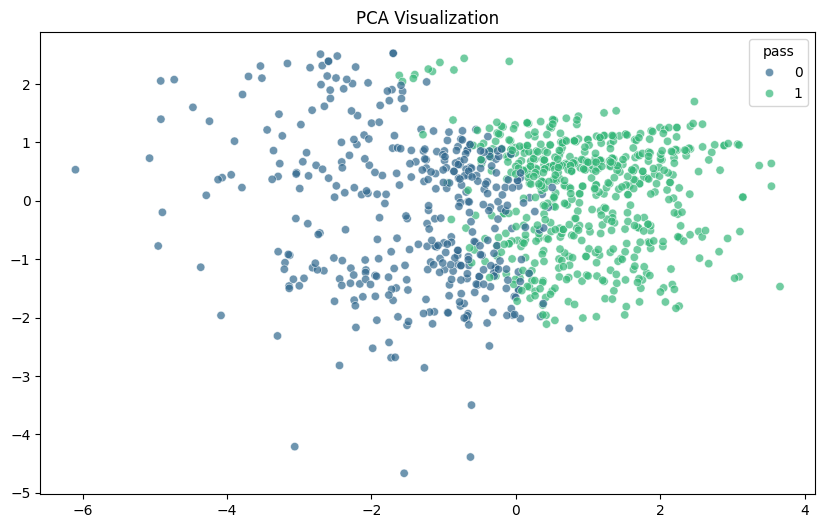

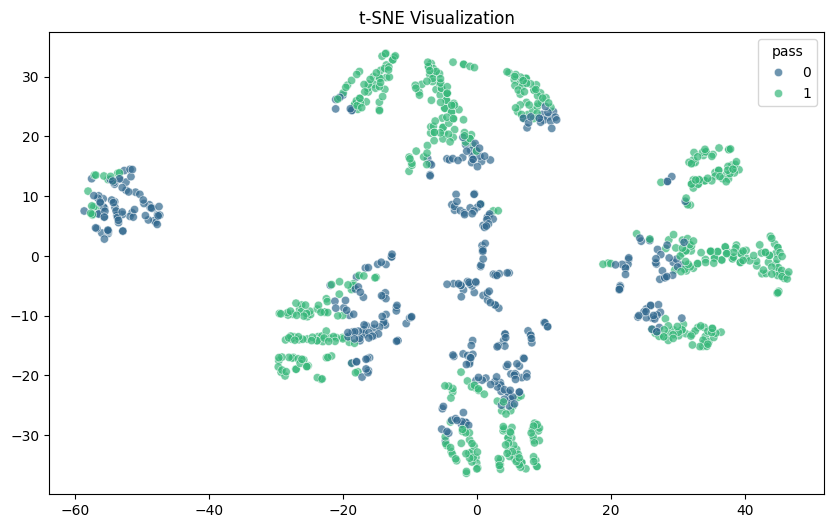

In [3]:
def plot_reduction(X, y, method="PCA"):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    reducer = PCA(n_components=2) if method == "PCA" else TSNE(n_components=2, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y, palette="viridis", alpha=0.7)
    plt.title(f"{method} Visualization")
    plt.show()

plot_reduction(X, y, "PCA")
plot_reduction(X, y, "t-SNE")

##  Systematic Model Training
We'll now run a series of experiments using different models and hyperparameters.

In [4]:
def train_and_log(model_name, model, X_tr, X_te, y_tr, y_te, params):
    with mlflow.start_run(run_name=model_name):
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        
        # Metrics
        metrics = {
            "accuracy": accuracy_score(y_te, preds),
            "precision": precision_score(y_te, preds, zero_division=0),
            "recall": recall_score(y_te, preds, zero_division=0),
            "f1": f1_score(y_te, preds, zero_division=0)
        }
        
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, "model")
        
        print(f"{model_name} -> Acc: {metrics['accuracy']:.4f}, Prec: {metrics['precision']:.4f}, Rec: {metrics['recall']:.4f}, F1: {metrics['f1']:.4f}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
print("Starting Experiments...")

## 1. Logistic Regression
for C in [0.1, 1.0, 10.0]:
    train_and_log("LogisticRegression", LogisticRegression(C=C, max_iter=1000), 
                  X_train_scaled, X_test_scaled, y_train, y_test, {"C": C})

## 2. KNN
for k in [3, 7]:
    train_and_log("KNN", KNeighborsClassifier(n_neighbors=k), 
                  X_train_scaled, X_test_scaled, y_train, y_test, {"k": k})

## 3. SVM
for C in [0.1, 1.0]:
    train_and_log("SVM", SVC(C=C), 
                  X_train_scaled, X_test_scaled, y_train, y_test, {"C": C})

## 4. Random Forest
for n in [50, 100]:
    train_and_log("RandomForest", RandomForestClassifier(n_estimators=n, random_state=42), 
                  X_train, X_test, y_train, y_test, {"n_estimators": n})

print("\nDone! Check MLflow UI for full details.")

Starting Experiments...


2026/05/07 20:30:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\Projet_ML_avance\venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/05/07 20:30:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LogisticRegression -> Acc: 0.9596, Prec: 0.9492, Rec: 0.9825, F1: 0.9655


d:\Projet_ML_avance\venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/05/07 20:30:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LogisticRegression -> Acc: 0.9596, Prec: 0.9569, Rec: 0.9737, F1: 0.9652


...

SVM -> Acc: 0.9343, Prec: 0.9469, Rec: 0.9386, F1: 0.9427


2026/05/07 20:31:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\Projet_ML_avance\venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


RandomForest -> Acc: 0.9495, Prec: 0.9483, Rec: 0.9649, F1: 0.9565


2026/05/07 20:31:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\Projet_ML_avance\venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


RandomForest -> Acc: 0.9596, Prec: 0.9649, Rec: 0.9649, F1: 0.9649

Done! Check MLflow UI for full details.
